In [12]:
import os, sys
import json

import polars as pl
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
import numpy as np

In [13]:
script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..', '..')

combined_dir = os.path.join(project_path, 'data', 'combined')
combined_path = os.path.join(combined_dir, 'processed_forms_interactions_data.parquet')

In [14]:
#Load combined_df
combined_df = pl.read_parquet(
    combined_path
)

In [ ]:
#column = "tool_usage_score"

print(combined_df[column].min())
print(combined_df[column].max())

ColumnNotFoundError: "tool_usage_score" not found

In [16]:
combined_df.columns

['id',
 'centro',
 'grupo',
 'puntuacion_tc_hake_gain',
 'puntuacion_tc_retencion_hake_gain',
 'puntuacion_tc_transferencia_hake_gain',
 'puntuacion_tc_hake_gain_cat',
 'puntuacion_tc_retencion_hake_gain_cat',
 'puntuacion_tc_transferencia_hake_gain_cat',
 'puntuacion_tc_units_hake_gain',
 'puntuacion_tc_retencion_units_hake_gain',
 'puntuacion_tc_transferencia_units_hake_gain',
 'puntuacion_tc_units_hake_gain_cat',
 'puntuacion_tc_retencion_units_hake_gain_cat',
 'puntuacion_tc_transferencia_units_hake_gain_cat',
 'mejora_hake_gain',
 'mejora_hake_gain_v2',
 'mejora_units_hake_gain',
 'niveles_mejora_hake_gain',
 'niveles_mejora_hake_gain_v2',
 'puntuacion_tc_cat_trad_scale_pre',
 'puntuacion_tc_cat_trad_scale_post',
 'marca temporal_pre',
 'marca temporal_post',
 'puntuacion_tc_pre',
 'puntuacion_ta_pre',
 'puntuacion_tc_retencion_pre',
 'puntuacion_tc_transferencia_pre',
 'puntuacion_tc_cat_pre',
 'puntuacion_ta_cat_pre',
 'puntuacion_tc_retencion_cat_pre',
 'puntuacion_tc_transfere

In [11]:
import numpy as np
from datetime import datetime, timedelta

def calculate_user_distribution_score(timestamps):
    """
    Calculates a score from 0.0 to 1.0 indicating how evenly distributed 
    a user's interactions are across their own timeline.
    
    Args:
        timestamps (list of datetime): List of interaction datetimes.
        
    Returns:
        float: Score between 0.0 (highly concentrated) and 1.0 (highly distributed).
    """
    # If there are fewer than 3 interactions, distribution cannot be meaningfully measured
    if not timestamps or len(timestamps) < 3:
        return 0.0
        
    # 1. Sort timestamps chronologically
    timestamps = sorted(timestamps)
    
    # 2. Calculate time differences (in seconds) between consecutive interactions
    timestamps_seconds = [t.timestamp() for t in timestamps]
    time_differences = np.diff(timestamps_seconds)
    
    # If all interactions occurred at the exact same second
    if np.sum(time_differences) == 0:
        return 0.0
        
    # 3. Sort differences in ascending order (required for Gini calculation)
    sorted_differences = np.sort(time_differences)
    n = len(sorted_differences)
    
    # 4. Calculate the raw Gini Coefficient
    indices = np.arange(1, n + 1)
    numerator = np.sum((2 * indices - n - 1) * sorted_differences)
    denominator = n * np.sum(sorted_differences)
    
    gini_raw = numerator / denominator
    
    # 5. Apply sample size correction so that the maximum Gini is always 1.0
    if n > 1:
        corrected_gini = gini_raw * (n / (n - 1))
    else:
        corrected_gini = gini_raw
    
    # Cap at 1.0 to handle potential floating-point precision errors
    corrected_gini = min(corrected_gini, 1.0)
    
    # 6. Invert the Gini index so 1 means "highly distributed" and 0 means "highly concentrated"
    score = 1.0 - corrected_gini
    
    return score

# ==========================================
# TEST CASES
# ==========================================

start_date = datetime(2026, 5, 1)

# Case 1: Distributed User (Interacts exactly once every day)
distributed_timestamps = [start_date + timedelta(days=i) for i in range(5)]

# Case 2: Concentrated User (Performs 4 actions in 3 minutes, then disappears for 4 days)
concentrated_timestamps = [
    start_date, 
    start_date + timedelta(minutes=1), 
    start_date + timedelta(minutes=2), 
    start_date + timedelta(minutes=3), 
    start_date + timedelta(minutes=10)
]

print(f"Distributed User Score: {calculate_user_distribution_score(distributed_timestamps):.4f}")
print(f"Concentrated User Score: {calculate_user_distribution_score(concentrated_timestamps):.4f}")

Distributed User Score: 1.0000
Concentrated User Score: 0.4000


#### Temporal Analysis

In [2]:
def compute_time_interval_variables(
    combined_df: pl.DataFrame
) -> pl.DataFrame:
    #Select relevant variables for analysis
    filtered_df = combined_df.select(
        #Identificadores Usuario
        "id",
        "grupo",
        "puntuacion_tc_hake_gain",
        
        #Variables Pre
        "marca temporal_pre",
        "puntuacion_tc_pre",
        
        #Variables Post
        "marca temporal_post",
        "puntuacion_tc_post",
        
        #Evaluation Timestamp
        "interactions_last_timestamp"
    )

    #Include Ganancia Unidades de Conocimiento
    filtered_df = filtered_df.with_columns(
        ganancia_conocimiento = (pl.col("puntuacion_tc_post") - pl.col("puntuacion_tc_pre"))*10
    )

    #Transform final_timestamp_interaction time
    filtered_df = filtered_df.with_columns(
        pl.col("interactions_last_timestamp")
        .dt.replace_time_zone("UTC")        # label it as UTC first (since it's naive)
        .dt.convert_time_zone("Europe/Madrid")  # converts respecting DST
        .dt.replace_time_zone(None)
        .alias("interactions_last_timestamp")
    )

    #Create groups (Instituto-Grupo)
    filtered_df = filtered_df.with_columns(
        class_group = (pl.col("id").str.split("-").list.get(0) + "_" + pl.col("grupo"))
    )
    
    #Transform temporal columns from str to datetime
    filtered_df = filtered_df.with_columns([
        pl.col("marca temporal_pre").str.to_datetime("%d/%m/%Y %H:%M:%S"),
        pl.col("marca temporal_post").str.to_datetime("%d/%m/%Y %H:%M:%S")
    ]).with_columns(
        pre_post_time_interval = (
            (pl.col("marca temporal_post") - pl.col("marca temporal_pre"))
            .dt.total_seconds()/60
        )
    )
    
    #Join DFs
    combined_df = combined_df.join(
        filtered_df,
        on="id",
        how="inner"
    )

    return combined_df

compute_time_interval_variables(
    combined_df=combined_df
)

NameError: name 'pl' is not defined

In [151]:
#Transform temporal columns from str to datetime
combined_df = combined_df.with_columns([
    pl.col("marca temporal_pre").str.to_datetime("%d/%m/%Y %H:%M:%S"),
    pl.col("marca temporal_post").str.to_datetime("%d/%m/%Y %H:%M:%S")
]).with_columns(
    (pl.col("marca temporal_post") - pl.col("marca temporal_pre"))
    .dt.total_minutes()
    .alias("full_experiment_duration"),
    (pl.col("interactions_last_timestamp") - pl.col("marca temporal_pre"))
    .dt.total_minutes()
    .alias("tool_usage_duration"),
)

In [152]:
combined_df

id,grupo,puntuacion_tc_hake_gain,marca temporal_pre,puntuacion_tc_pre,marca temporal_post,puntuacion_tc_post,interactions_last_timestamp,ganancia_conocimiento,class_group,full_experiment_duration,tool_usage_duration
str,str,f64,datetime[μs],f64,datetime[μs],f64,datetime[μs],f64,str,i64,i64
"""RamiroMaeztu-ks0""","""experimental""",1.0,2026-02-18 09:07:05,0.6,2026-02-18 09:43:17,1.0,2026-02-18 09:31:26.747,4.0,"""RamiroMaeztu_experimental""",36,24
"""RamiroMaeztu-pu9""","""experimental""",1.0,2026-02-18 09:05:17,0.8,2026-02-18 09:43:40,1.0,2026-02-18 09:38:20.082,2.0,"""RamiroMaeztu_experimental""",38,33
"""RamiroMaeztu-8jb""","""experimental""",1.0,2026-02-18 09:05:30,0.6,2026-02-18 09:44:03,1.0,2026-02-18 09:38:32.086,4.0,"""RamiroMaeztu_experimental""",38,33
"""RamiroMaeztu-x5e""","""experimental""",0.0,2026-02-18 09:08:19,0.6,2026-02-18 09:44:57,0.6,2026-02-18 09:28:05.093,0.0,"""RamiroMaeztu_experimental""",36,19
"""RamiroMaeztu-80a""","""experimental""",0.5,2026-02-18 09:05:34,0.8,2026-02-18 09:45:32,0.9,2026-02-18 09:29:17.468,1.0,"""RamiroMaeztu_experimental""",39,23
…,…,…,…,…,…,…,…,…,…,…,…
"""Laguna-r45""","""experimental""",0.0,2026-04-10 09:40:13,0.7,2026-04-10 10:21:28,0.7,2026-04-10 09:57:39.812,0.0,"""Laguna_experimental""",41,17
"""Laguna-lqw""","""experimental""",0.4,2026-04-10 09:39:18,0.5,2026-04-10 10:21:52,0.7,2026-04-10 10:06:30.771,2.0,"""Laguna_experimental""",42,27
"""Laguna-chn""","""experimental""",0.2,2026-04-10 09:37:49,0.5,2026-04-10 10:22:10,0.6,2026-04-10 10:00:01.047,1.0,"""Laguna_experimental""",44,22


### Experiment Duration

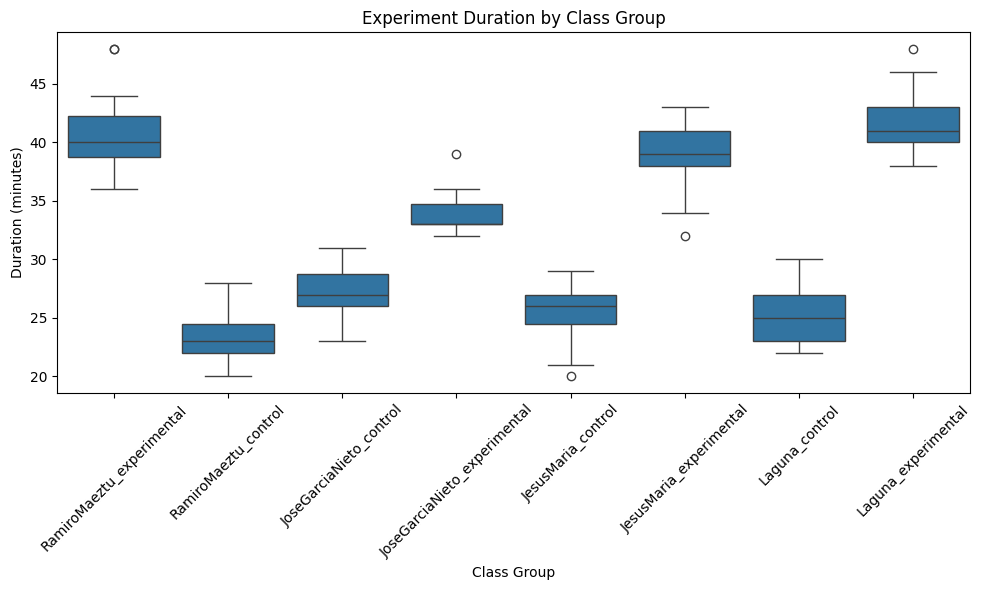

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=combined_df.to_pandas(),
    x="class_group",
    y="full_experiment_duration",
    ax=ax
)

ax.set_title("Experiment Duration by Class Group")
ax.set_xlabel("Class Group")
ax.set_ylabel("Duration (minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

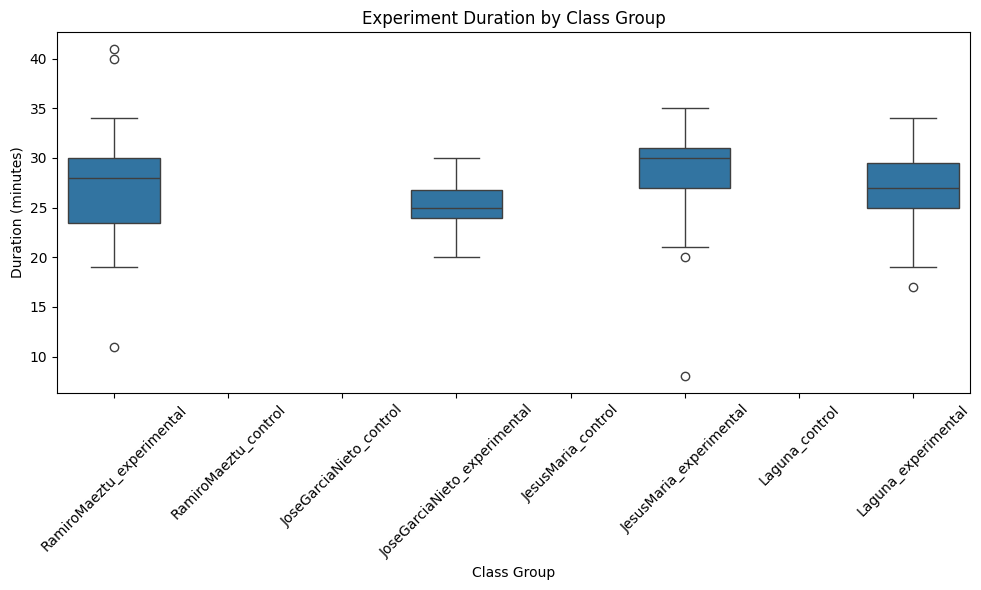

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=combined_df.to_pandas(),
    x="class_group",
    y="tool_usage_duration",
    ax=ax
)

ax.set_title("Experiment Duration by Class Group")
ax.set_xlabel("Class Group")
ax.set_ylabel("Duration (minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Puntuacion Pre

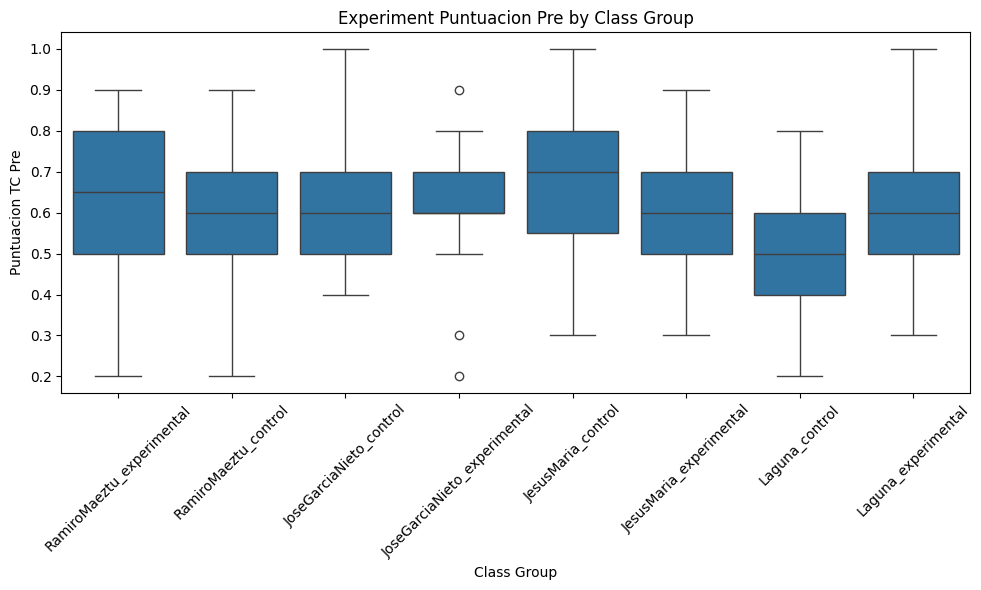

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=combined_df.to_pandas(),
    x="class_group",
    y="puntuacion_tc_pre",
    ax=ax
)

ax.set_title("Experiment Puntuacion Pre by Class Group")
ax.set_xlabel("Class Group")
ax.set_ylabel("Puntuacion TC Pre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Puntuacion Post

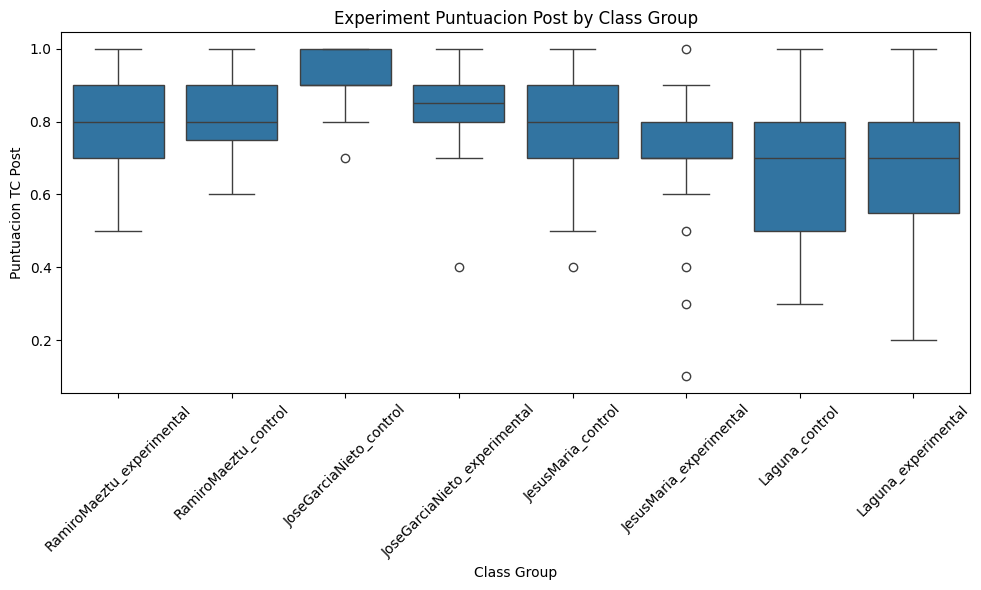

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=combined_df.to_pandas(),
    x="class_group",
    y="puntuacion_tc_post",
    ax=ax
)

ax.set_title("Experiment Puntuacion Post by Class Group")
ax.set_xlabel("Class Group")
ax.set_ylabel("Puntuacion TC Post")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Ganancia de Hawke y Ganancia Unidades de Conocimiento

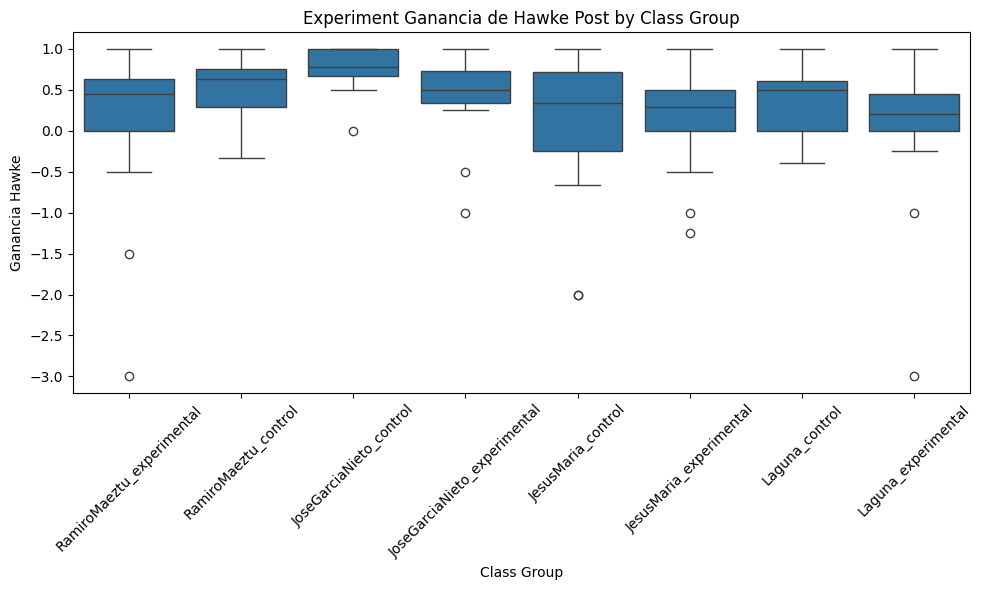

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=combined_df.to_pandas(),
    x="class_group",
    y="puntuacion_tc_hake_gain",
    ax=ax
)

ax.set_title("Experiment Ganancia de Hawke Post by Class Group")
ax.set_xlabel("Class Group")
ax.set_ylabel("Ganancia Hawke")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

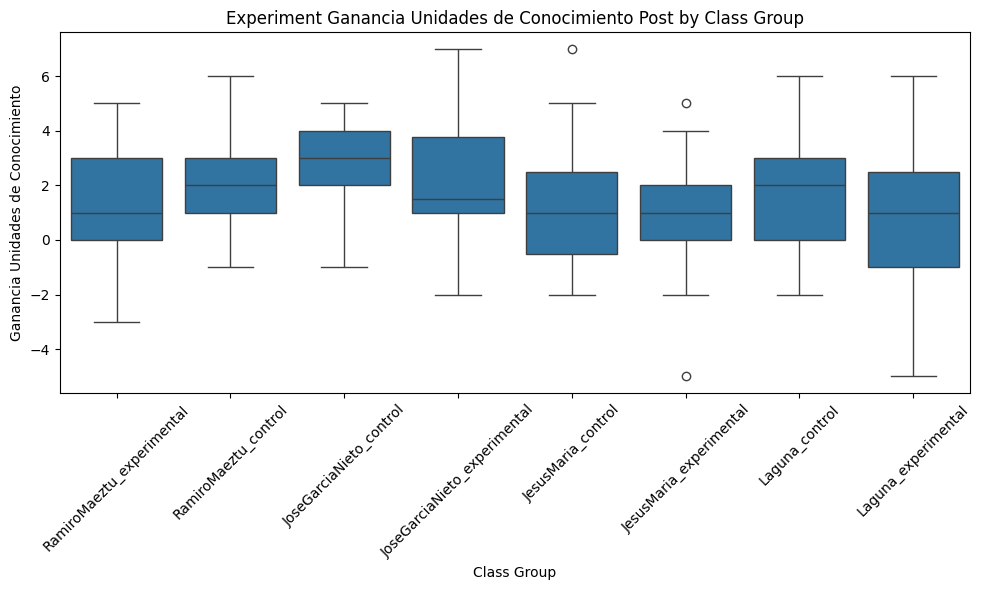

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=combined_df.to_pandas(),
    x="class_group",
    y="ganancia_conocimiento",
    ax=ax
)

ax.set_title("Experiment Ganancia Unidades de Conocimiento Post by Class Group")
ax.set_xlabel("Class Group")
ax.set_ylabel("Ganancia Unidades de Conocimiento")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

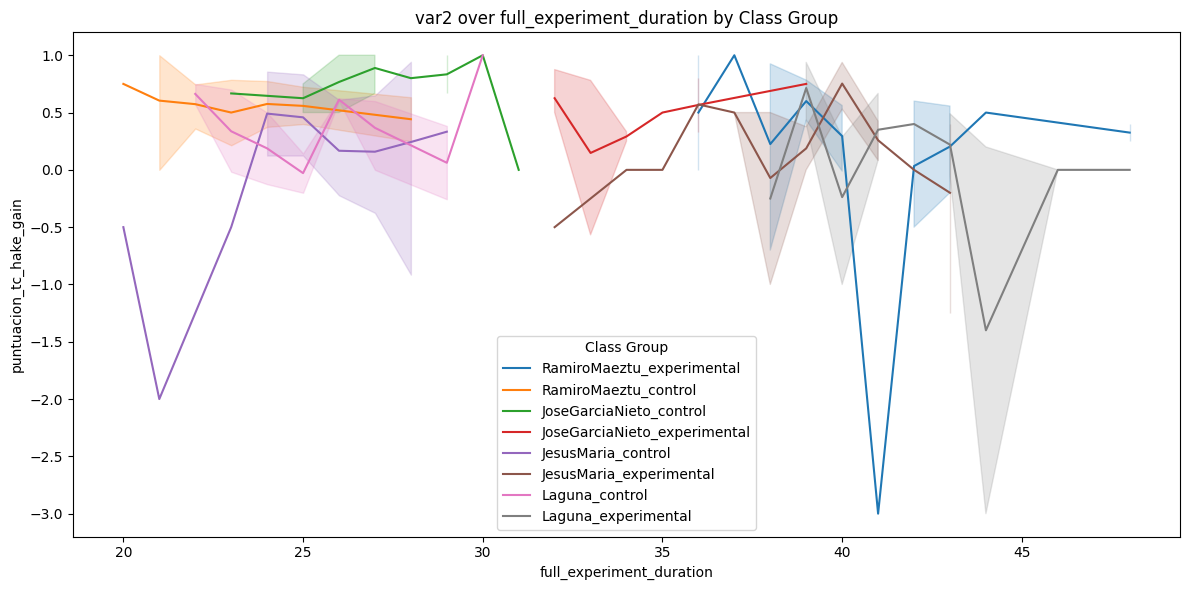

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=combined_df.to_pandas(),
    x="full_experiment_duration",
    y="puntuacion_tc_hake_gain",
    hue="class_group",
    ax=ax
)

ax.set_title("var2 over full_experiment_duration by Class Group")
ax.set_xlabel("full_experiment_duration")
ax.set_ylabel("puntuacion_tc_hake_gain")
plt.legend(title="Class Group")
plt.tight_layout()
plt.show()

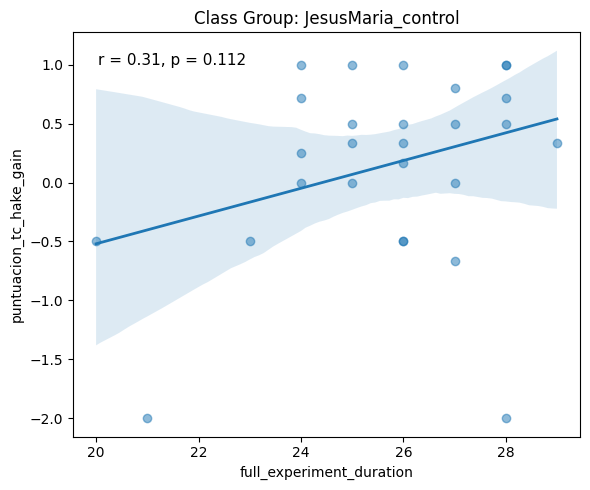

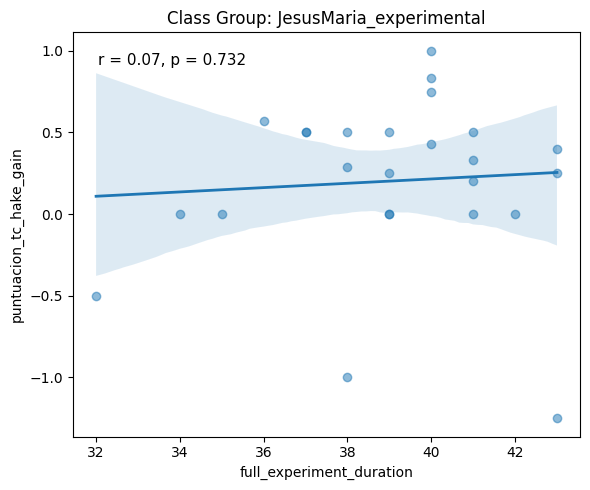

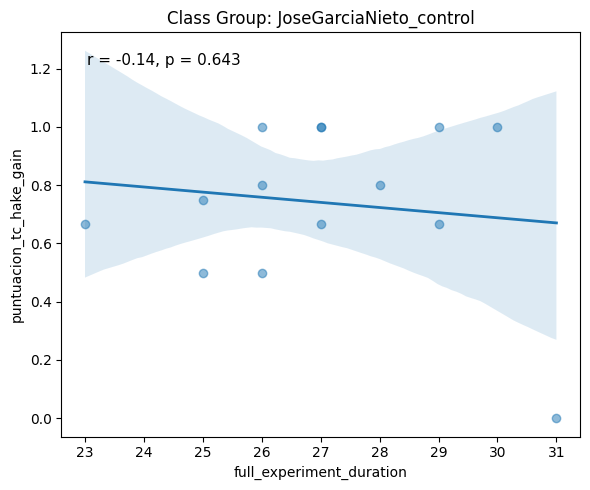

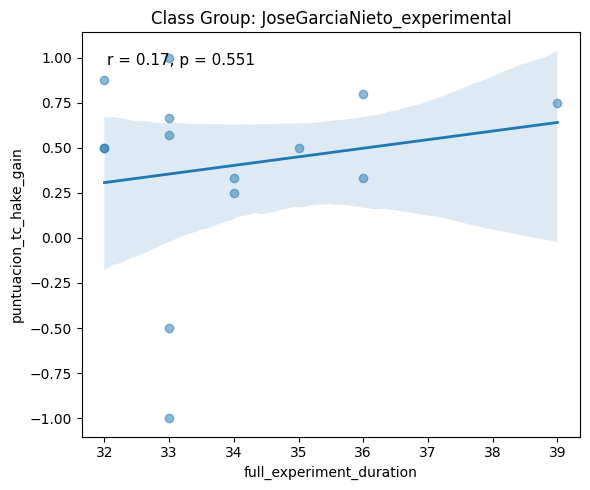

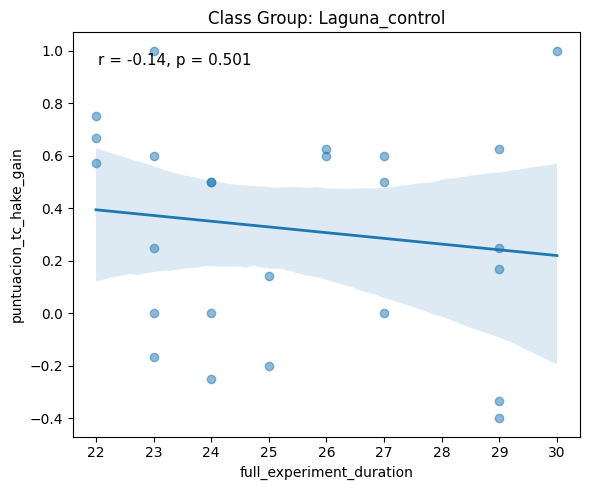

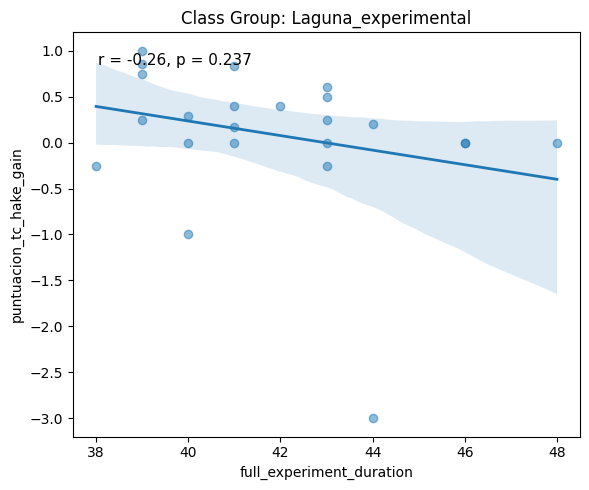

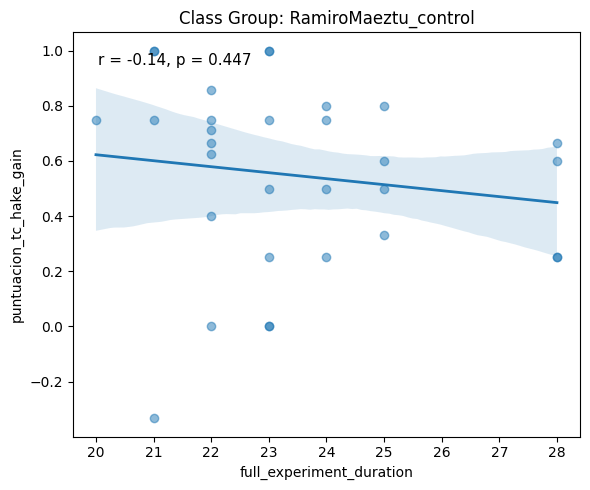

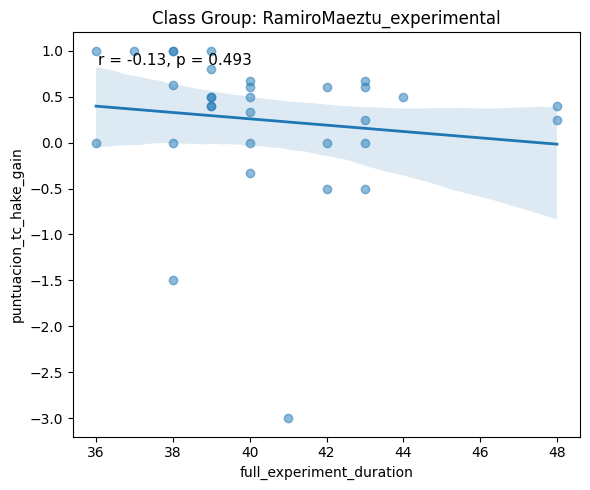

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

for group, gdf in combined_df.to_pandas().groupby("class_group"):
    fig, ax = plt.subplots(figsize=(6, 5))
    
    sns.regplot(
        data=gdf,
        x="full_experiment_duration",
        y="puntuacion_tc_hake_gain",
        scatter_kws={"alpha": 0.5},
        line_kws={"linewidth": 2},
        ax=ax
    )
    
    # Correlation annotation
    r, p = stats.pearsonr(gdf["full_experiment_duration"].dropna(), gdf["puntuacion_tc_hake_gain"].dropna())
    ax.annotate(f"r = {r:.2f}, p = {p:.3f}", xy=(0.05, 0.95),
                xycoords="axes fraction", fontsize=11,
                verticalalignment="top")
    
    ax.set_title(f"Class Group: {group}")
    ax.set_xlabel("full_experiment_duration")
    ax.set_ylabel("puntuacion_tc_hake_gain")
    plt.tight_layout()
    plt.show()